In [1]:
# first quick look at the data from jill's test platform run

In [2]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Sans'
# plt.rcParams['figure.figsize'] = (3,2)
# plt.rcParams["figure.dpi"] = 300
import os

In [41]:
overDF = pd.read_csv('./output/newAmpTRES.CSV')

noMagDF = pd.read_csv('./output/noMagTRES7.CSV')

In [42]:
noMagDF

,timecode,seconds,lat,lat_dir,lon,lon_dir,sensor
0,260411_222030_000,80430.000,0.0000,NaN,0.0000,NaN,513
1,260411_222030_435,80430.438,0.0000,NaN,0.0000,NaN,515
2,260411_222030_534,80430.531,0.0000,NaN,0.0000,NaN,513
3,260411_222030_634,80430.633,0.0000,NaN,0.0000,NaN,513
4,260411_222030_734,80430.734,0.0000,NaN,0.0000,NaN,514
...,...,...,...,...,...,...,...
18018,260411_225032_200,82232.203,4159.9819,N,8739.4277,W,512
18019,260411_225032_300,82232.297,4159.9819,N,8739.4277,W,512
18020,260411_225032_400,82232.398,4159.9819,N,8739.4277,W,512
18021,260411_225032_500,82232.500,4159.9819,N,8739.4277,W,512


In [43]:
overDF['sensor'] = pd.to_numeric(overDF['sensor'], errors='coerce')
overDF['sensor']

overDF['seconds'] = pd.to_numeric(overDF['seconds'], errors='coerce')

In [44]:
noMagSens = np.array(noMagDF['sensor'])

noMagSecs = np.array(noMagDF['seconds'])

In [45]:
# noMagSens = noMagSens[1000:-1000]
# noMagSecs = noMagSecs[1000:-1000]

noMagVolt = noMagSens * 5 / 1023#16383

In [46]:
overSens = np.array(overDF['sensor'])

overSecs = np.array(overDF['seconds'])

In [47]:
overSens = overSens[1000:-1000]
overSecs = overSecs[1000:-1000]

In [60]:
overVolt = overSens * 5 / 1023#16383

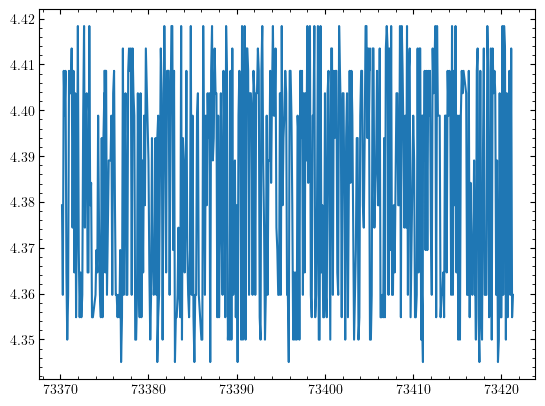

In [61]:
plt.plot(overSecs,overVolt)

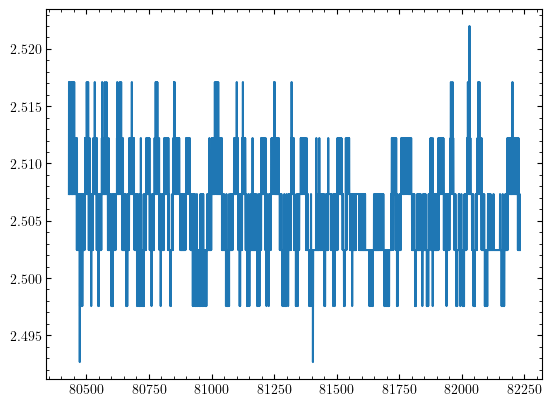

In [62]:
plt.plot(noMagSecs,noMagVolt)
# plt.xlim(71000,72000)

In [51]:
# maybe this low frequency osc is an issue with the grounding of inputs into the amp, will check all wiring today

In [52]:
noMagF,noMagPSD = sp.signal.welch(noMagVolt,fs=100,nperseg=300)

[]

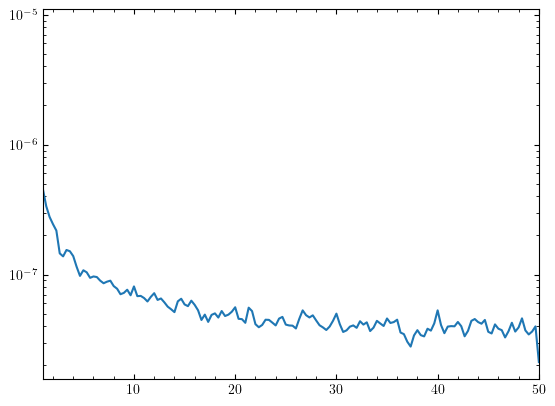

In [55]:
plt.plot(noMagF,noMagPSD)
plt.xlim(1,50)
plt.semilogy()

In [56]:
overF,overPSD = sp.signal.welch(overVolt,fs=100,nperseg=300)

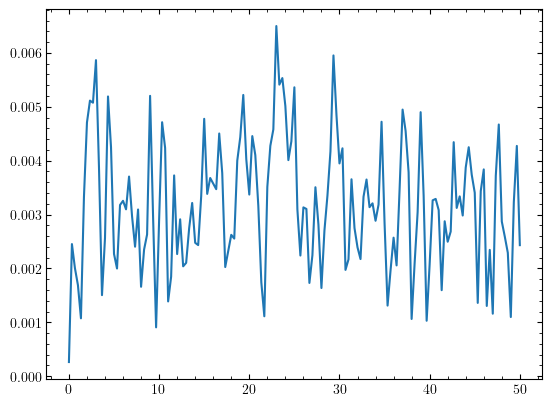

In [57]:
plt.plot(overF,np.sqrt(overPSD))
# plt.xlim(10,50)
# plt.ylim(1e-10,1e-8)
# plt.semilogy()

Text(0, 0.5, '$V/\\sqrt{Hz}$')

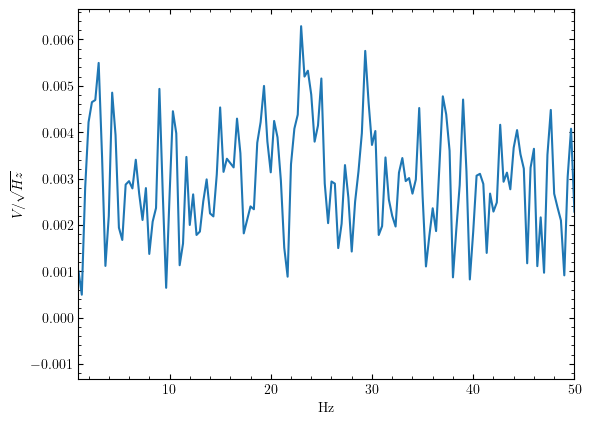

In [59]:
plt.plot(overF,(np.sqrt(overPSD)-np.sqrt(noMagPSD)))
plt.xlim(1,50)
# plt.ylim(0.00002,0.0001)
plt.xlabel('Hz')
plt.ylabel(r'$V/\sqrt{Hz}$')
# plt.semilogy()